In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
import warnings

# 경로 설정
import os
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 모델링
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgbm
from catboost import CatBoostRegressor

# 평가지표
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# 파이프라인
from sklearn.pipeline import Pipeline

# 출력 설정
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# 시드 설정
np.random.seed(42)
random_seed = 42

print("-" * 60)
print("라이브러리 로드 완료")
print("한글 폰트 설정 완료!")
print("-" * 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
if not os.getcwd().endswith("airbnb_price_prediction"):
    os.chdir(os.path.abspath(".."))
print(os.getcwd())

d:\Dev\airbnb_price_prediction


In [3]:
# 이 경로에서 원하는 데이터로 변경
def load_borough_data(base_path, borough_name):
    """
    특정 자치구 폴더에서 6개의 CSV 파일을 로드하여 반환합니다.
    """

    if borough_name == "manhattan":
        suffix = "mnh"
    elif borough_name == "brooklyn":
        suffix = "bkl"
    else:
        suffix = borough_name

    path = f"{base_path}/{borough_name}"

    X_train = pd.read_csv(f"{path}/X_train_{suffix}.csv")
    y_train = pd.read_csv(f"{path}/y_train_{suffix}.csv").squeeze()
    X_test = pd.read_csv(f"{path}/X_test_{suffix}.csv")
    y_test = pd.read_csv(f"{path}/y_test_{suffix}.csv").squeeze()
    ids_train = pd.read_csv(f"{path}/ids_train_{suffix}.csv")
    ids_test = pd.read_csv(f"{path}/ids_test_{suffix}.csv")

    return X_train, y_train, X_test, y_test, ids_train, ids_test


base = "data"

# 보고 싶은 파트를 바꾸면 됨!
X_train, y_train, X_test, y_test, ids_train, ids_test = load_borough_data(base, "manhattan")

In [4]:
xgb_reg = xgb.XGBRegressor(random_state=random_seed, n_jobs=-1, verbosity=1, tree_method="hist")

# 우리는 요정도만! 설정해볼까요? + 처음에 n_estimators를 작게하고 다른 것들을 좁혀나가다가, n_estimators를 늘려가는 식으로가 팁!
# 우선 100 ~ 300으로 하다가, 어느 정도 된 거 같으면 n_estimator 늘려보기
# 다중공선성 체크 안 하고 변수 다 때려넣었으니, L1 규제(유의미하지 않으면 0으로 만드는 규제) 사용해보기
# 과적합 우려가 높기 때문에, min_child_weight 사용해보기
param_grid = {
    "n_estimators": [500],
    "max_depth": [6],
    "learning_rate": [0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [3],
    "alpha": [0.4],
}

grid_cv = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)

# model_cv = RandomizedSearchCV(
#    estimator=xgb_reg,
#    param_distributions=param_grid,
#    n_iter=100,
#    scoring="neg_mean_squared_error",
#    cv=3,
#    n_jobs=-1,
#    verbose=3,
#    return_train_score=True,
#    random_state=random_seed,
# )

grid_cv.fit(X_train, y_train)
print(f"최적 파라미터 : {grid_cv.best_params_}")
print(f"최적 RMSE : {grid_cv.best_score_}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
최적 파라미터 : {'alpha': 0.4, 'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 500, 'subsample': 0.8}
최적 RMSE : -0.09935443603515212


In [5]:
cv_df = (
    pd.DataFrame(grid_cv.cv_results_)[
        [
            "param_n_estimators",
            "param_max_depth",
            "param_learning_rate",
            "param_subsample",
            "param_colsample_bytree",
            "param_min_child_weight",
            "param_alpha",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
        ]
    ]
    .rename(
        columns={
            "param_n_estimators": "n_estimators",
            "param_max_depth": "max_depth",
            "param_learning_rate": "learning_rate",
            "param_subsample": "subsample",
            "param_colsample_bytree": "colsample_bytree",
            "mean_train_score": "훈련 정확도",
            "mean_test_score": "검증 정확도",
            "std_test_score": "표준편차",
            "rank_test_score": "순위",
        }
    )
    .sort_values("순위")
)

cv_df.head(20)

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,param_min_child_weight,param_alpha,훈련 정확도,검증 정확도,표준편차,순위
0,500,6,0.05,0.8,0.8,3,0.4,-0.00828,-0.099354,0.00424,1


In [6]:
best_model = grid_cv.best_estimator_
pred_final = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_final))
rmse2 = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_final)))
r2 = r2_score(y_test, pred_final)
mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(pred_final))

print(f"교차검증 RMSE: {grid_cv.best_score_:.3f}")
print(f"Log Root Mean Squared Error: {rmse:.3f}")
print(f"결정 계수 : {r2 * 100:.3f}%")
print()

print(f"원래 가격의 RMSE : {rmse2:.3f}")
print(f"원래 가격의 MAPE : {mape * 100:.3f}%")

교차검증 RMSE: -0.099
Log Root Mean Squared Error: 0.313
결정 계수 : 73.579%

원래 가격의 RMSE : 76.641
원래 가격의 MAPE : 23.984%


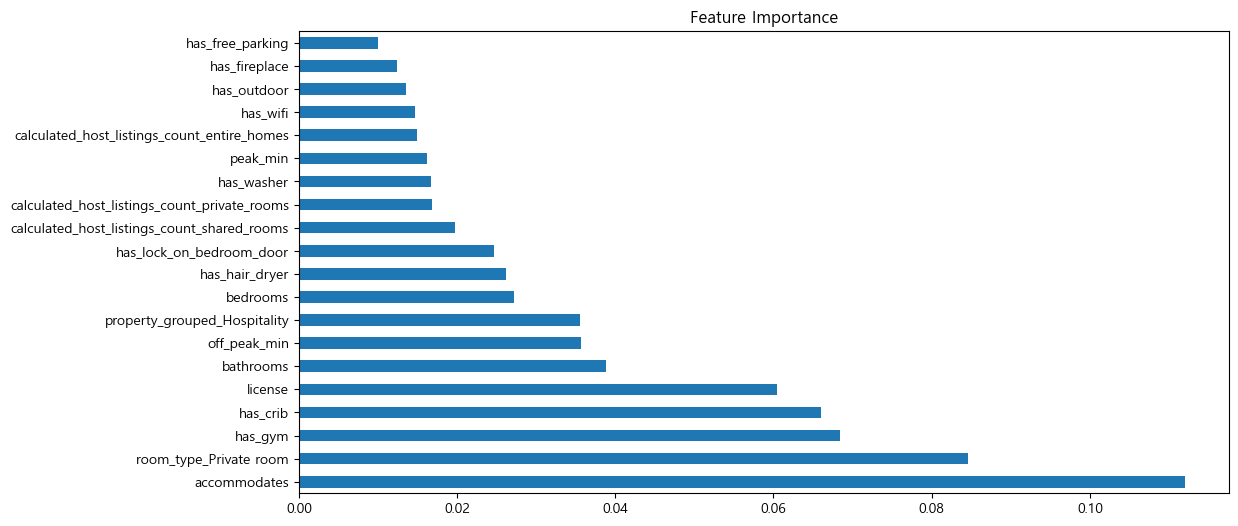

In [7]:
# 최적의 모델에서 피처 중요도 뽑기
import matplotlib.pyplot as plt

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(20).plot(kind="barh")
plt.title("Feature Importance")
plt.show()

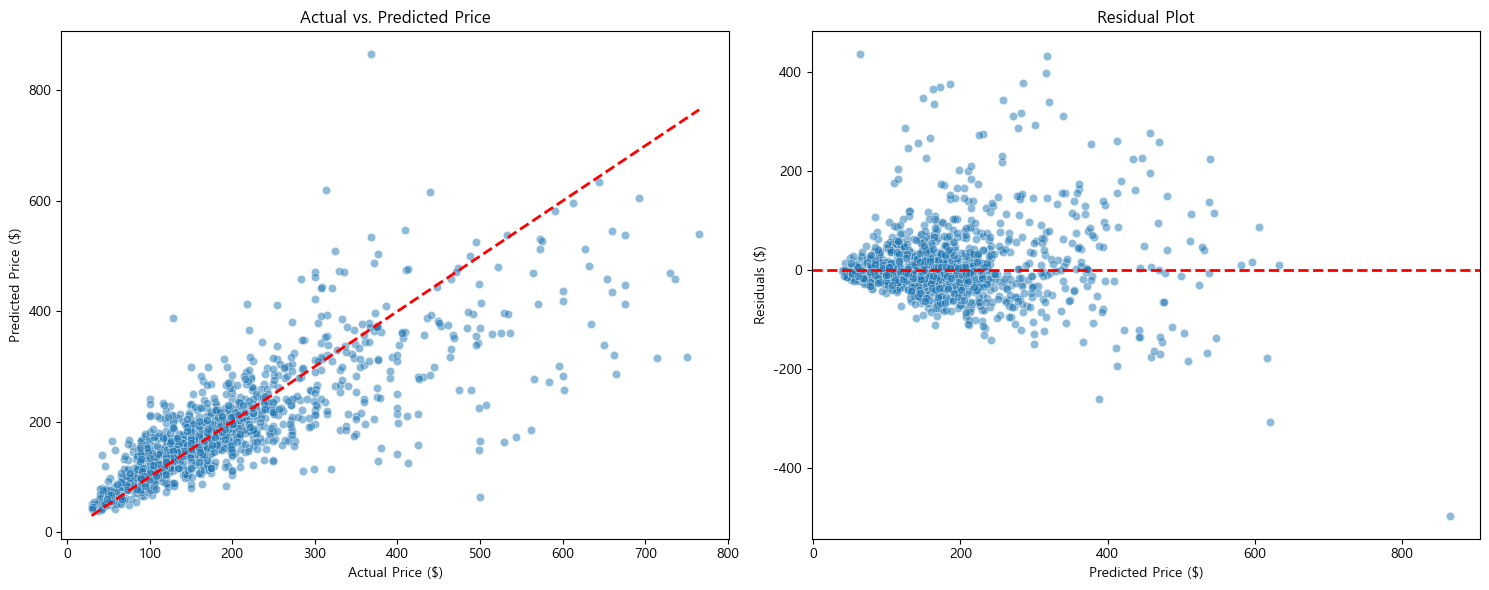

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (로그 단위를 원본 달러 단위로 복원)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(pred_final)
residuals = y_test_orig - y_pred_orig

# 시각화 설정
plt.figure(figsize=(15, 6))

# 그래프 1: 실제값 vs 예측값 (Actual vs Predicted)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_orig, y=y_pred_orig, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], "r--", lw=2)
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs. Predicted Price")

# 그래프 2: 잔차도 (Residual Plot)
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_orig, y=residuals, alpha=0.5)
plt.axhline(y=0, color="r", linestyle="--", lw=2)
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residuals ($)")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

In [9]:
X_train.shape

(4783, 90)

In [ ]:
import shap # 모델의 내부 부스터 객체를 추출해서 전달 
explainer = shap.TreeExplainer(best_model.get_booster()) shap_values = explainer.shap_values(X_test) 
# 시각화 shap.summary_plot(shap_values, X_test)

In [11]:
best_model = grid_cv.best_estimator_
best_model.save_model("xgb_mht_model.json")